In [36]:
#imports
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
import sys
import os
from astropy.cosmology import Planck18 as cosmo
import ast




In [38]:
# --- User toggle ---
Cristina = True
Shar = not Cristina 

# --- System Configurations ---

if Cristina:
    print("[CONFIG] Using Cristina's local MacBook setup")
    sys.path.insert(0, "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/Users/andradenebula/rubin_sim_data"
    db_dir = "/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub"
    base_dir = '/Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output'
    
elif Shar:
    print("[CONFIG] Using Shar's Dirac server setup")
    sys.path.insert(0, "/lustre/lrspec/metrics")
    sys.path.insert(0, "/home/3155/metrics/Multi_Transient_Metrics_Hub")
    os.environ["RUBIN_SIM_DATA_DIR"] = "/lustre/lrspec/metrics/rubin_sim_data"
    db_dir = "/lustre/lrspec/metrics"
    base_dir = '/lustre/lrspec/metrics/results'

# Shared config
sys.path.append(os.path.abspath(".."))  # For shared_utils


[CONFIG] Using Cristina's local MacBook setup


In [44]:
#this happens twice because idk why but it only works like that
#...you still have to run it twice if it gives warnings
# C: Make sure you save your metric file before running. 

metric_filename = "new_names_local_GRBafterglows_metric"
s_u = "shared_utils"

# --- Reload metric module ---
if metric_filename in sys.modules:
    del sys.modules[metric_filename]
metric = __import__(metric_filename)
importlib.reload(metric)

# --- Reload shared_utils module ---
if s_u in sys.modules:
    del sys.modules[s_u]
shared_utils = __import__(s_u)
importlib.reload(shared_utils)

print(f"[INFO] Loaded metric module: {metric_filename}")
print(f"[INFO] Loaded shared_utils module")




/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric new_names_local_GRBafterglows_metric.Base_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric new_names_local_GRBafterglows_metric.Detect_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt/anaconda3/envs/rubin_sim_223/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric new_names_local_GRBafterglows_metric.GRBAfterglowCharacterizeMetric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/opt

[INFO] Loaded metric module: new_names_local_GRBafterglows_metric
[INFO] Loaded shared_utils module


In [46]:
use_kcorrect=True
k_correct_type='powerlaw'
k_correct_arg=-.75

#metric configurations
testname=None
num_lightcurves=1000
#use this to add text to the filename
#if you're testing template or population variables other than the below variables

testname_metric_only=None 
#use this to add text to the filename for the observation record df only (does not change pop/template filenames)
#so for anything you're changing that's only about the detection criteria

#control whether we generate new files - 
#new files will still generate if these are false and it can't find a file with the correct parameters
#so recommend leaving it on false
generate_new_templates = False 
generate_new_pop = False
make_debug_plots = True #toggle whether or not the pop generation makes plots

#population variables
rate_density = 1e-9

# apply None for non-use case 
z_min, z_max = .00226, 4.5
d_min, d_max = None, None #3000, 4000

#other
gal_lat_cut = None #latitude cut, for Galactic phenomena
use_extinction = True
t_start = 1 #start time in days
t_end = 3652

# Whether to remove Metric_temp_* folders after running
clean_temp = True  # <- NEW toggle

#cadence variables
cadences = ['four_roll_v4.3.1_10yrs'] #'baseline_v4.3.1_10yrs','noroll_v3.6_10yrs']
#cadences = ['four_roll_v5.0.0_10yrs']#, 'baseline_v5.0.0_10yrs','noroll_v3.6_10yrs','baseline_v3.6_10yrs']
ignore_triples = True #turn this to true to ignore triples

# Standardized output paths for this science case
# paths = metric.get_output_paths(case_label="GRBafterglows")  # <- can change to 'KNe' etc.
paths = shared_utils.build_filenames(testname=testname,
                        testname_metric_only=testname_metric_only,
                        science_case="GRBafterglows", 
                        rate_density=rate_density, 
                        z_min=z_min, 
                        z_max=z_max,
                        d_min=d_min, 
                        d_max=d_max,
                        ignore_triples=ignore_triples,                   
                        use_extinction=use_extinction,
                        use_kcorrect=use_kcorrect,
                        base_dir=base_dir)


templates_file, pop_file, df_file, storage_dir, summary_filename = paths

GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-4.5_Mpc_ext_True_kcor_True_None


In [48]:
#load and/or generate light curves
shared_lc_model = shared_utils.load_or_generate_templates(metric.LC,
    templates_file=templates_file,
    generate_new=generate_new_templates, num_lightcurves=num_lightcurves
)

[INFO] Loading light curve templates from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-4.5_Mpc_ext_True_kcor_True_None_templates.pkl.
Loaded GRB afterglow templates from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-4.5_Mpc_ext_True_kcor_True_None_templates.pkl


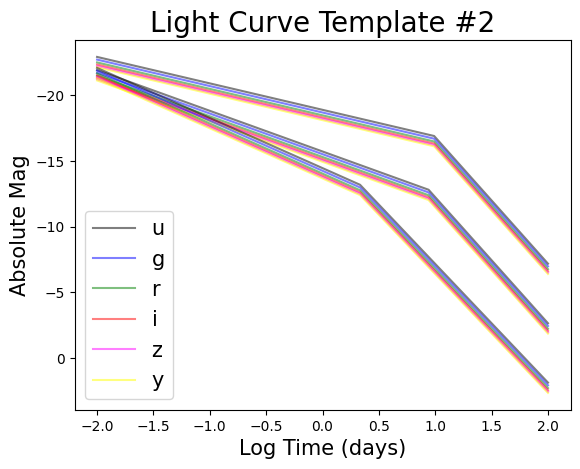

In [50]:
#plot light curves from pkl file if desired
shared_utils.plot_some_lcs_from_pkl(templates_file, num=3, use_log_time=True, plot_overlap=True)

In [52]:
# Load or generate population slicer
slicer = shared_utils.load_or_generate_population(use_extinction=use_extinction,
    lc_model=shared_lc_model,
    t_start=t_start,
    t_end=t_end,
    d_min=d_min,
    d_max=d_max,
    z_min=z_min,
    z_max=z_max,
    seed=42,
    num_lightcurves=num_lightcurves, #technically should read this from the file
    gal_lat_cut=gal_lat_cut,
    rate_density=rate_density,
    pop_file=pop_file,
    generate_new=generate_new_pop,
    make_debug_plots=make_debug_plots
)


[INFO] Loading population from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-4.5_Mpc_ext_True_kcor_True_None_population.pkl
Loaded population from /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-4.5_Mpc_ext_True_kcor_True_None_population.pkl


In [54]:
shared_utils.get_kcorrection_powerlaw(np.array([1,4]), 'y', spectral_index=-.75)

array([1.31700623, 3.05799377])

In [56]:
shared_utils.get_kcorrection_blackbody(np.array([.05,1,2,4]), 'u', temperature=10000)

array([ 0.10874672,  2.73033789,  6.06364269, 13.38102463])

## All 10 years


--- Running four_roll_v4.3.1_10yrs ---
EBV included

Inspecting one obs_record before saving to CSV:
mjd_obs         | type: <class 'list'> | length: 743
mag_obs         | type: <class 'list'> | length: 743
snr_obs         | type: <class 'list'> | length: 743
filter          | type: <class 'list'> | length: 743
first_det_mjd   | type: <class 'float'> | value: nan
last_det_mjd    | type: <class 'float'> | value: nan
fade_time_days  | type: <class 'float'> | value: nan
sid_duplicate   | type: <class 'numpy.int64'> | value: 1
file_indx       | type: <class 'numpy.int64'> | value: 806
ra              | type: <class 'numpy.float64'> | value: 0.6135923151542564
dec             | type: <class 'numpy.float64'> | value: -0.5848608108840141
distance_Mpc    | type: <class 'numpy.float64'> | value: 3367.314610871189
peak_mjd_observed | type: <class 'numpy.float64'> | value: 61620.305312357516
peak_mag_observed | type: <class 'numpy.float64'> | value: 36.894366914821646
ebv             | type: <cl

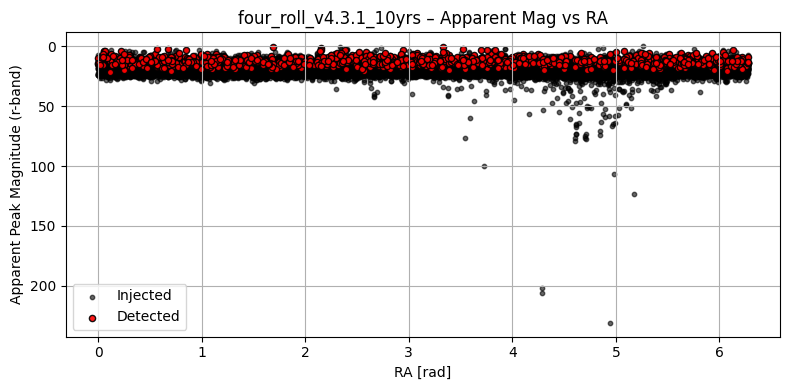

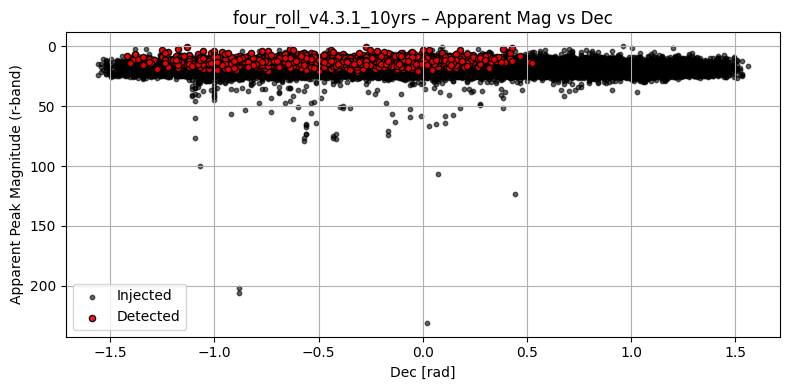

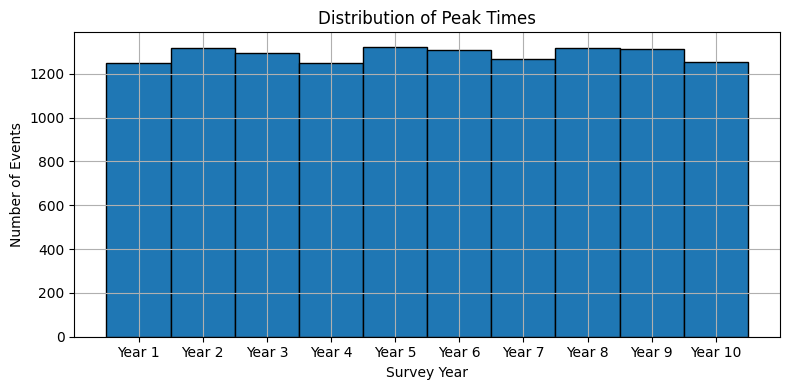

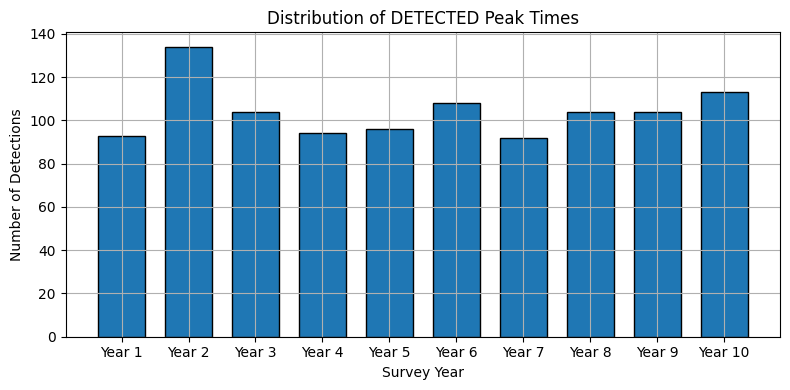

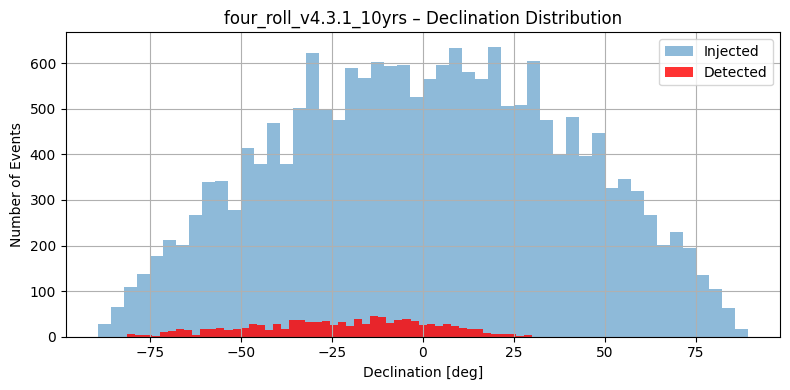

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/GRBafterglows/Metric_temp_four_roll_v4.3.1_10yrs


In [59]:
#run detection metric
df_obs = shared_utils.run_detect(metric, 
                                 slicer, 
                                 cadences, 
                                 shared_lc_model, 
                                 db_dir, storage_dir, 
                                 df_file, 
                                 ignore_triples=ignore_triples, 
                                 debug=True, plot=True, 
                                 clean_temp=clean_temp,
                                 use_kcorrect=use_kcorrect,
                                 k_correct_type=k_correct_type,
                                 k_correct_arg=k_correct_arg,
                                 use_extinction=use_extinction)

In [60]:
#choose what to run in run_multi_metrics
# we can remove historical if we want
multi_metrics = metric.get_multi_metrics(shared_lc_model, include=[ 'detect','spec_trigger'], use_extinction=use_extinction, use_kcorrect=use_kcorrect, k_correct_type=k_correct_type, k_correct_arg=k_correct_arg)



--- Running four_roll_v4.3.1_10yrs ---
(2,)
[<new_names_local_GRBafterglows_metric.Detect_Metric object at 0x3b15f2810>, <new_names_local_GRBafterglows_metric.GRBAfterglowSpecTriggerableMetric object at 0x3b15f49d0>]
EBV included
                                         Sum                     run  \
four_roll_v4.3.1_10yrs_Detect_Metric  1060.0  four_roll_v4.3.1_10yrs   

                                      n_events_full_sky  
four_roll_v4.3.1_10yrs_Detect_Metric              18975  
[DEBUG] Detected RA, Dec: 131.48, 7.18
[DEBUG] Detected RA, Dec: 213.05, -32.80
[DEBUG] Detected RA, Dec: 81.67, -70.17


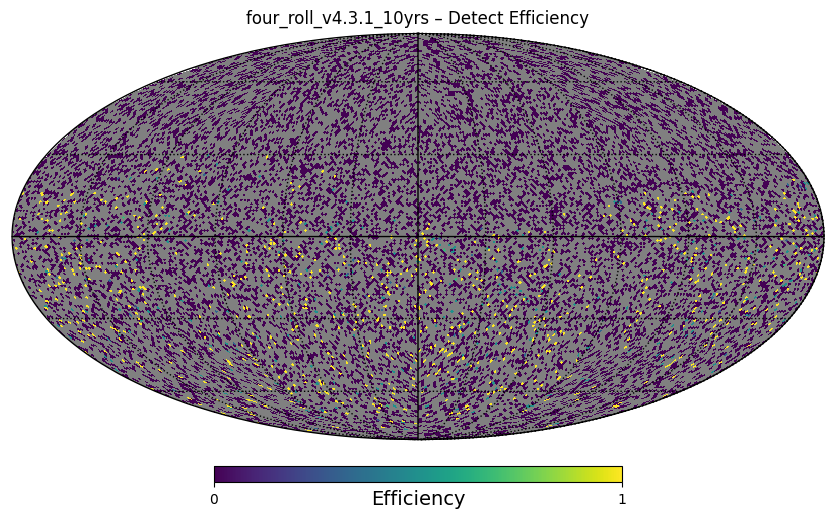

EBV included
[DEBUG] Detected RA, Dec: 303.05, -10.81
[DEBUG] Detected RA, Dec: 135.70, 10.81


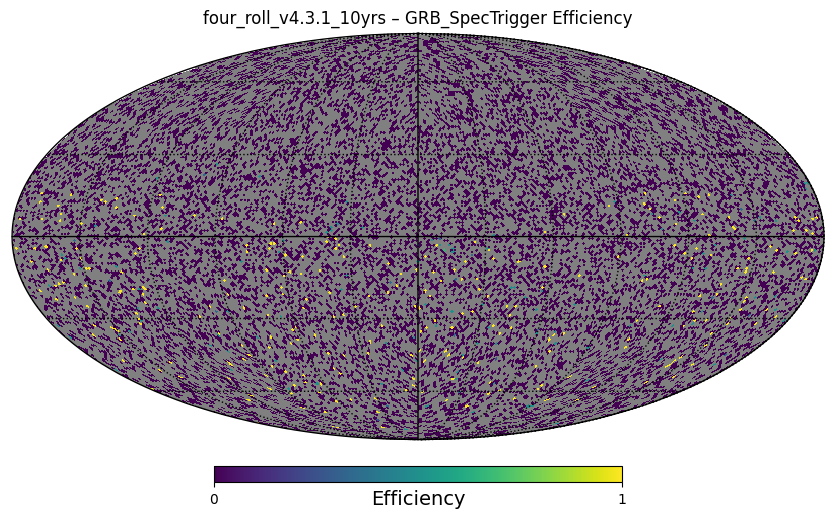

[CLEANUP] Removing temp directory: /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/GRBafterglows/Metric_temp_four_roll_v4.3.1_10yrs
saved summary to  /Users/andradenebula/Documents/Research/Transient_Metrics/Multi_Transient_Metrics_Hub/output/GRBafterglows/GRBafterglows_den_1e-09_d_None-None_Mpc_z_0.00226-4.5_Mpc_ext_True_kcor_True_None_None_it_True_multi_summary.csv


In [61]:
summary_df_1 = shared_utils.run_multi_metrics(multi_metrics, 
                                              slicer, cadences, shared_lc_model, 
                                              db_dir, storage_dir, 
                                              summary_filename=summary_filename, ignore_triples=False, plot=True, clean_temp=clean_temp, use_extinction=use_extinction)

In [62]:
summary_df_1

,Sum,run,n_events_full_sky
four_roll_v4.3.1_10yrs_Detect_Metric,1060.0,four_roll_v4.3.1_10yrs,18975
four_roll_v4.3.1_10yrs_GRBAfterglowSpecTriggerableMetric,417.0,four_roll_v4.3.1_10yrs,18975


In [ ]:
# Convert to numeric safely
valid_peak_mags = pd.to_numeric(detected_df['peak_mag_observed'], errors='coerce')

# Remove NaNs and cap at 99
valid_peak_mags = valid_peak_mags[np.isfinite(valid_peak_mags) & (valid_peak_mags < 99)]

# Plot
plt.figure(figsize=(8, 4))
plt.hist(valid_peak_mags, bins=30, edgecolor='black', color='red')
plt.xlabel("Apparent Peak Magnitude")
plt.ylabel("Number of Detected GRB Afterglows")
plt.title("Distribution of Apparent Peak Magnitudes (Detected GRB Afterglows)")
plt.gca().invert_xaxis()
plt.grid(True)
plt.tight_layout()
plt.show()


KeyError: 'injected_peak_ebv_mag_r'